## Processamento Digital de Imagens - PDI - 2026.1

### Prof. Francisco Zampirolli
### Prof. Celso Kurashima




***

# **Aula 9 - parte 2 - Transformada de Distância**  em Segmentação de Imagens

***


# **1 - Definições de Segmentação**

A **segmentação de imagens** é o processo de dividir uma imagem em múltiplas regiões, cada uma correspondendo a um objeto ou área de interesse específico. As técnicas de segmentação geralmente se baseiam em duas propriedades fundamentais dos níveis de cinza:

### 1.1 Descontinuidades

* **Objetivo:** Identificar e separar regiões da imagem com mudanças abruptas nos níveis de cinza.
* **Aplicações:**
    * Detecção de pontos isolados
    * Detecção de linhas
    * Detecção de bordas

### 1.2 Similaridades

* **Objetivo:** Agrupar pixels com características visuais semelhantes em regiões homogêneas.
* **Técnicas:**
    * **Limiarização:** Define um valor de limiar para separar pixels em primeiro plano e fundo.
    * **Crescimento de regiões:** Expande regiões a partir de sementes, agregando pixels com similaridade aos pixels da região.
    * **Divisão e fusão de regiões:** Divide regiões grandes em menores e/ou une regiões menores em maiores, buscando otimizar uma medida de qualidade.

**Outras Considerações:**

* **Características visuais:** Além dos níveis de cinza, outras características podem ser utilizadas para a segmentação, como cor, textura, forma e movimento.
* **Aplicações:** A segmentação de imagens tem diversas aplicações, como processamento de imagens médicas, visão computacional, análise de vídeo e reconhecimento de padrões.

## **2 - Limiarização** (*Thresholding*)

A **limiarização** é uma técnica fundamental em processamento de imagens, amplamente utilizada para segmentar imagens em regiões de primeiro plano e fundo. Consiste em escolher um valor de limiar (threshold) que separa os pixels da imagem em duas classes distintas.

**Conceito:**
* **Histograma:** Um histograma representa a distribuição dos níveis de cinza em uma imagem. Na limiarização, busca-se identificar um valor de limiar que separa os picos correspondentes ao primeiro plano e ao fundo.
* **Limiar:** O valor de limiar é um ponto de corte que determina se um pixel pertence ao primeiro plano ou ao fundo. Pixels com valores de cinza acima do limiar são classificados como primeiro plano, e os demais como fundo.

**Tipos de Limiarização:**
* **Global:** Um único valor de limiar é aplicado a toda a imagem.
* **Local:** Diferentes valores de limiar são calculados para regiões locais da imagem, adaptando-se a variações de iluminação.

**Aplicações:**
* **Binarização:** Conversão de uma imagem em escala de cinza para uma imagem binária (preto e branco).
* **Segmentação de objetos:** Isolamento de objetos de interesse em uma imagem.
* **Pré-processamento:** Preparação de imagens para outras técnicas de processamento, como detecção de bordas e reconhecimento de padrões.

**Exemplo:**
Imagine uma imagem de uma moeda sobre um fundo escuro. O histograma da imagem apresentará dois picos distintos: um correspondente aos pixels da moeda (primeiro plano) e outro correspondente aos pixels do fundo. O valor de limiar será escolhido entre os dois picos para separar as duas regiões.

**Observações:**

* A escolha do valor de limiar pode ser feita de forma manual ou automática, utilizando algoritmos como Otsu, que busca encontrar o limiar ótimo de forma automática.
* A limiarização é uma técnica simples e eficiente, mas pode ser sensível a ruídos e variações de iluminação.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [8]:
!pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nayar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


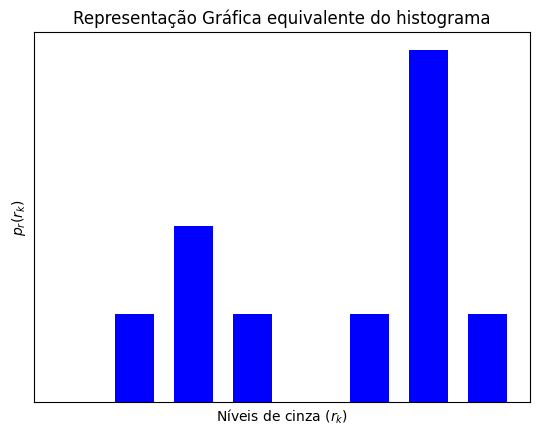

In [17]:
import plotly.express as px
pr = [0.0, 0.1, 0.2, 0.1, 0.0, 0.1, 0.4, 0.1]
n = len(pr)
x = range(n)
width = 1/1.5
plt.bar(x, pr, width, color="blue")
plt.ylabel('$p_r(r_k)$', fontsize=10)
plt.xlabel('Níveis de cinza ($r_k$)', fontsize=10)
plt.title('Representação Gráfica equivalente do histograma')
plt.xticks([]), plt.yticks([])
plt.show()

## Limiarização (*Thresholding*) - equação

- Uma maneira de extrair os objetos do fundo é através da **seleção de um limiar $T$ que separe os dois grupos**;
- **Hipótese:** a escala de níveis de cinza do objeto de interesse é diferente da escala de níveis de cinza do fundo da imagem.

$$ g(x,y) = \left \{ \begin{array}{cc}
1 & se \ f(x,y) > T \\
0 & se \ f(x,y) \leq T
\end{array}
 \right .
$$



# **3 - Segmentação Baseada em Região**

- **Detecção de bordas e limiarização** às vezes não dão bons resultados para segmentação.

- A segmentação em região é baseada na **conectividade de pixels similares** em uma região:

    - Cada região deve ser uniforme.

    - A conectividade dos pixels dentro de uma região é muito importante.

- Há duas aproximações de segmentação baseadas na análise de região:

  * **Crescimento de região** e

  * **Divisão de região**.

## Segmentação Baseada em Região

- $ R $ representa a região da imagem inteira.
- A segmentação é um processo que particiona $ R $ em sub-regiões $ R_1, R_2, \ldots, R_n $, de forma que:

    - (a) $ \cup_{i=1}^n R_i = R $
    - (b) $ R_i $ é uma região conectada, para $ i=1,2,\ldots,n $
    - (c) $ R_i \cap R_j = \emptyset $, para todos $ i $ e $ j $, onde $ i \neq j $
    - (d) $ P(R_i) = \text{VERDADEIRO} $ para $ i=1,2,\ldots,n $
    - (e) $ P(R_i \cup R_j) = \text{FALSO} $ para quaisquer regiões adjacentes de $ R_i $ e $ R_j $

onde $ P(R_k) $: Propriedade definida para a região é verdadeira para todos os pixels da região.

**Exemplo:** $ P(R_k) = \text{VERDADEIRA} $ se todos os pixels em $ R_k $ têm os mesmos valores de níveis de cinza.

## Agregação de pixels usado em Crescimento de Regiões

- Agrupamento de pixels ou formação de grupos de pixels em regiões maiores.
- Os pixels a serem agrupados devem ter propriedades similares (nível de cinza, textura, cor, etc.).
- O processo inicia-se com um conjunto de “sementes” em torno do qual as regiões crescem.
- A seleção das sementes depende da natureza do problema.
- A escolha das propriedades que estabelecem os critérios de similaridade depende do tipo de dados disponíveis.

**Exemplo:** Em aplicações militares que utilizam imagens com ponto infravermelho, os pontos mais quentes, e portanto mais brilhantes, são de particular interesse.

# **4 - Segmentação Usando Watershed**

- Watershed, em geografia, refere-se às saliências que dividem as áreas inundadas por diferentes rios (bacias hidrográficas).
- A área que armazena água é chamada de bacia, formada pelas partes mais fundas.
- A Transformada Watershed aplica essas ideias em imagens em nível de cinza para a segmentação.

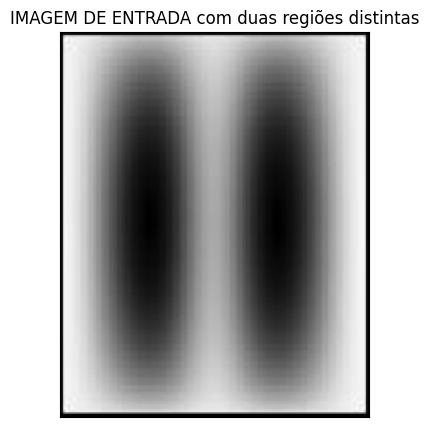

In [11]:
#  Leitura da imagem com duas regiões distintas
img_a = cv2.imread('figura_a.png')
plt.figure(figsize=(5,5))
plt.imshow(img_a,"gray"),plt.title('IMAGEM DE ENTRADA com duas regiões distintas')
plt.xticks([]), plt.yticks([])
plt.show()

### Conceituação em Watershed

- Bacias Hidrográficas (Catchment Basins) e Linhas Divisórias (Watershed Lines)

- A Imagem é vista como a Topografia 3D de uma área onde o valor da intensidade do pixel é plotado no eixo $z$, em cada coordenada $(x,y)$.

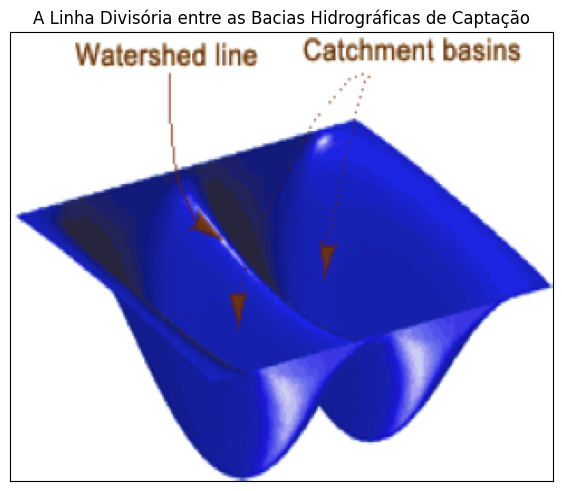

In [12]:
# Bacias Hidrográficas (Catchment Basins) e Linhas Divisórias (Watershed Lines)
img_b = cv2.imread('figura_b.png')
plt.figure(figsize=(7,7))
plt.imshow(img_b,"gray")
plt.title('A Linha Divisória entre as Bacias Hidrográficas de Captação')
plt.xticks([]), plt.yticks([])
plt.show()

### Inundação *Watershed*

- A chuva que cai nesta área vai escorrer e ocupar as partes mais baixas do terreno.

- A água que cair exatamente sobre a linha divisória (Watershed) terá a mesma probabilidade de escorrer para qualquer uma das bacias por ela dividida.

- A Transformada Watershed segmenta as regiões considerando as áreas inundadas entre as linhas de Watershed como as regiões da imagem.

- Se enchermos essa superfície de um mínimo e prevenirmos a mistura das águas originárias de diferentes pontos, a imagem será separada em diferentes conjuntos:

    - As **Bacias de Captação** (catchment basins) e
    - As **Linhas de Watershed** (watershed lines).

### **Exemplo** de aplicação utilizando **Transformada de Distância**, para a segmentação por *Watershed*.



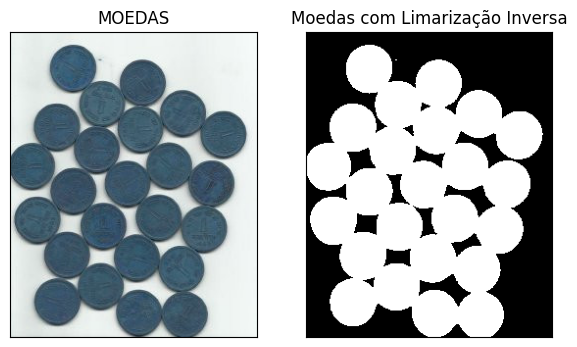

In [13]:
# PASSO 1. Carregar imagem e converter para escala de cinza
# USAR A LIMIARIZAÇÃO. Ex.: Método OTSU
#
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('water_coins.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

img_ori = img.copy()

# PASSO 2. Binarização (Limiarização de Otsu)
ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

plt.figure(figsize=(7,7))
plt.subplot(121),plt.imshow(img,"gray"),plt.title('MOEDAS')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(thresh,"gray"),plt.title('Moedas com Limarização Inversa')
plt.xticks([]), plt.yticks([])
plt.show()


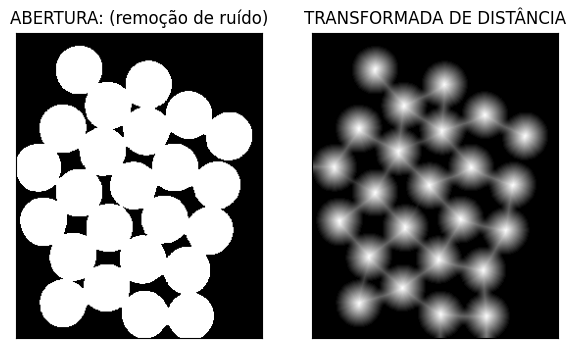

In [14]:
# PASSO 3. Remoção de ruído (Morfologia)
#
# Ex.: ABERTURA
# Esta imagem será utilizada posteriormente na Transformada de Distância
#
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel, iterations = 2)

# PASSO 4. Transformada de Distância
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)


plt.figure(figsize=(7,7))
plt.subplot(121),plt.imshow(opening,"gray"),plt.title('ABERTURA: (remoção de ruído)')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(dist_transform,"gray"),plt.title('TRANSFORMADA DE DISTÂNCIA')
#plt.subplot(122),plt.imshow(sure_bg,"gray"),plt.title('DILATAÇÃO: sure_bg (área de fundo)')
plt.xticks([]),plt.yticks([])
plt.show()
#
# OBSERVE: NO PLANO DE FUNDO ÁREAS PODEM FICAR "CONECTADAS"
#


### Transformada de Distância com OpenCV

Cria um gradiente de distância. Transforma formas planas em "montanhas" de dados.



Valor máximo de pico =  23.968996
LIMIAR: 70% desse valor =  16.778297


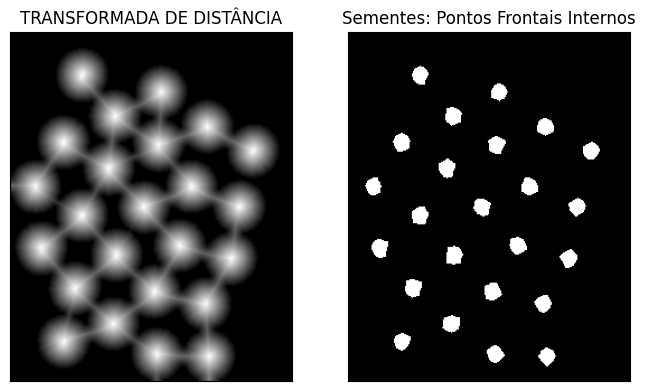

In [18]:
# PASSO 5. Obter o "Foreground de Certeza"

# OBS. Na célular anterior foi executado:
# dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
# Mostre agora o valor máximo:
#
print('Valor máximo de pico = ', dist_transform.max())
print('LIMIAR: 70% desse valor = ', 0.7*dist_transform.max())

# "Foreground de Certeza" obtido por Limiarização
# Finding sure foreground area
#
ret, sure_fg = cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)

# Mostrar imagens:
plt.figure(figsize=(8,5))
plt.subplot(121),plt.imshow(dist_transform,"gray"),plt.title('TRANSFORMADA DE DISTÂNCIA')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(sure_fg,"gray"),plt.title('Sementes: Pontos Frontais Internos')
plt.xticks([]),plt.yticks([])
plt.show()

# OBSERVE:
# Filtra apenas os picos da distância.
# Garante que cada objeto tenha apenas um ponto central (semente).
#

#### **Watershed Continua na próxima aula.**

Teremos:

*   Gerar MARCADORES
*   Rotular - *Label*
*   Aplicar Watershed
*   Segmentar

In [ ]:
#- - - - - -

In [15]:
# EXEMPLO COMPLETO DE SEGMENTAÇÃO POR WATERSHED
#

import cv2
import numpy as np

# 1. Carregar imagem e converter para escala de cinza
img = cv2.imread('water_coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Binarização (Limiarização de Otsu)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3. Remoção de ruído (Morfologia)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 4. Transformada de Distância
# Calculamos a distância de cada pixel branco ao pixel preto mais próximo
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# 5. Obter o "Foreground de Certeza"
# Pegamos apenas os picos da transformada de distância
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# 6. Marcadores para o Watershed
sure_fg = np.uint8(sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)

# Adicionamos 1 a todos os labels para que o fundo seja 1 e não 0
markers = markers + 1
# Marcamos a região desconhecida (fronteiras) como 0
unknown = cv2.subtract(cv2.dilate(opening, kernel, iterations=3), sure_fg)
markers[unknown == 255] = 0

# 7. Aplicar Watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0] # Bordas em vermelho

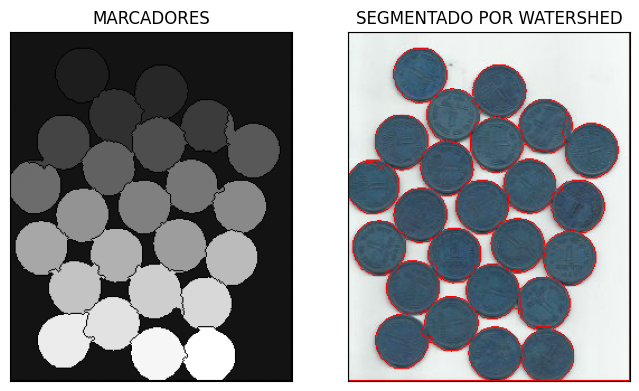

In [16]:
# Mostrar imagens:
plt.figure(figsize=(8,5))
plt.subplot(121),plt.imshow(markers,"gray"),plt.title('MARCADORES')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(img,"gray"),plt.title('SEGMENTADO POR WATERSHED')
plt.xticks([]),plt.yticks([])
plt.show()

- - - - -